In [99]:
#%pip install openpyxl

In [100]:
#%pip install xlrd

In [101]:
#%pip install pandas

In [ ]:
#%pip install matplotlib

In [156]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
data = pd.read_excel(
    r'C:\Users\KS\Desktop\รวมข้อมูลยอดขาย.xlsx'
)


In [ ]:
data.drop(index=59 , inplace=True)

เปลี่ยน Type DATE

In [105]:
data['DATE'] = pd.to_datetime(data['DATE'],errors='coerce')

In [125]:
data.dtypes

DATE                                                 datetime64[ns]
K1                                                          float64
K2                                                          float64
K3                                                          float64
K4                                                          float64
K5                                                          float64
SP                                                          float64
PET                                                         float64
รวมยอดขาย K SP PET                                          float64
KS หน้าร้านไทย ปลีก                                         float64
KS หน้าร้าน Malay ปลีก                                      float64
KS ยอดขายปลีกรวม                                            float64
KS ขายสดหลังร้าน                                            float64
KS ขายเชื่อหน้าร้าน เชื่อ                                   float64
KS ขายSp+Kmart เชื่อ                            

only Show DATE is Blank

In [126]:
data[data['DATE'].isna()]['DATE']

Series([], Name: DATE, dtype: datetime64[ns])

แปลงข้อมูลตัวเลขให้อยู่ในแบบ float64

In [127]:
Float64 = data.select_dtypes(include='number').columns
data[Float64] = data[Float64].astype('float64')

แปลงข้อมูลให้อยู่รูปวันที่วันที่

In [138]:
data.dtypes

DATE                                                 datetime64[ns]
K1                                                          float64
K2                                                          float64
K3                                                          float64
K4                                                          float64
K5                                                          float64
SP                                                          float64
PET                                                         float64
รวมยอดขาย K SP PET                                          float64
KS หน้าร้านไทย ปลีก                                         float64
KS หน้าร้าน Malay ปลีก                                      float64
KS ยอดขายปลีกรวม                                            float64
KS ขายสดหลังร้าน                                            float64
KS ขายเชื่อหน้าร้าน เชื่อ                                   float64
KS ขายSp+Kmart เชื่อ                            

In [133]:
data.drop(columns=['New_Column'] , inplace=True)

In [136]:
data.groupby('QUARTER')['K1'].sum()

QUARTER
1.0    6099478.0
2.0    6296274.0
3.0    6552895.0
4.0    6985380.0
Name: K1, dtype: float64

In [149]:
data['ยอดรวมไตรมาส K1 68']  = data.groupby('QUARTER')['K1'].transform(sum)

C:\Users\KS\AppData\Local\Temp\ipykernel_15332\2582454738.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  data['ยอดรวมไตรมาส K1 68']  = data.groupby('QUARTER')['K1'].transform(sum)


In [146]:
data[data['QUARTER'] == 1]['ยอดรวมไตรมาส K1 68'] 

0     6099478.0
1     6099478.0
2     6099478.0
3     6099478.0
4     6099478.0
        ...    
86    6099478.0
87    6099478.0
88    6099478.0
89    6099478.0
90    6099478.0
Name: ยอดรวมไตรมาส K1 68, Length: 90, dtype: float64

In [ ]:
data['YEAR_MONTH'] = data['DATE'].dt.to_period('M')

In [118]:
data.groupby('YEAR_MONTH')['PET'].sum()


YEAR_MONTH
2025-01    651458.0
2025-02    556845.0
2025-03    584310.0
2025-04    565223.0
2025-05    584336.0
2025-06    549909.0
2025-07    583749.0
2025-08    563379.0
2025-09    546062.0
2025-10    443309.0
2025-11    514161.0
2025-12    508196.0
Freq: M, Name: PET, dtype: float64

<Axes: xlabel='DATE', ylabel='K1'>

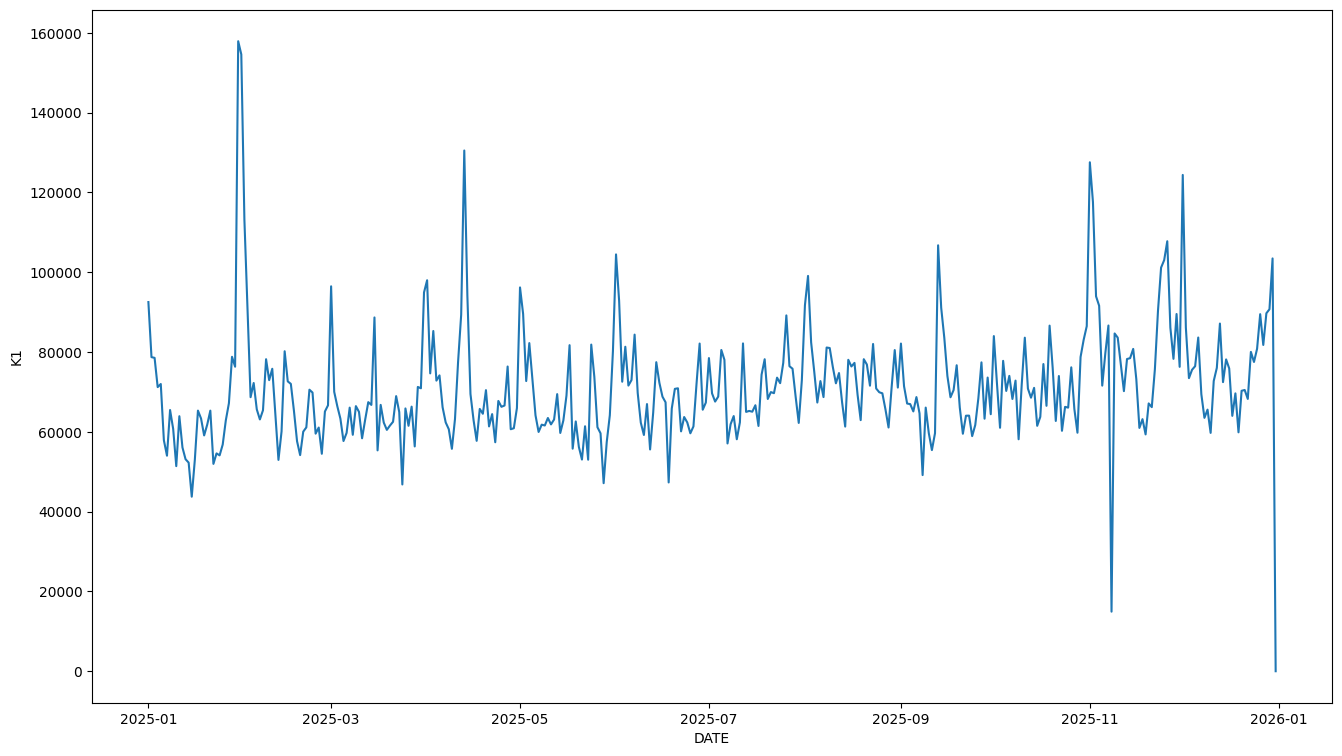

In [ ]:
plt.rcParams['figure.figsize'] = (16,9)
sns.lineplot(data=data ,x=data['DATE'] , y=data['K1'])